In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('weather_cleaned.csv')
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour
0,2006-03-31 22:00:00+00:00,19,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197,2006,3,31,22
1,2006-03-31 23:00:00+00:00,19,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197,2006,3,31,23
2,2006-04-01 00:00:00+00:00,17,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197,2006,4,1,0
3,2006-04-01 01:00:00+00:00,19,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197,2006,4,1,1
4,2006-04-01 02:00:00+00:00,17,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197,2006,4,1,2


In [4]:
X = df.drop(columns=['Temperature (C)', 'Formatted Date'])
y = df['Temperature (C)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [7]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Kết quả Linear Regression:")
print("MAE =", mae_lr)
print("MSE =", mse_lr)
print("RMSE =", rmse_lr)
print("R2 =", r2_lr)

Kết quả Linear Regression:
MAE = 0.7436364747717562
MSE = 0.9047926729392899
RMSE = 0.9512059045965231
R2 = 0.9901326209530923


In [8]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Kết quả Random Forest:")
print("MAE =", mae_rf)
print("MSE =", mse_rf)
print("RMSE =", rmse_rf)
print("R2 =", r2_rf)

Kết quả Random Forest:
MAE = 0.013115993754831658
MSE = 0.0023460997475620326
RMSE = 0.04843655383656059
R2 = 0.9999744141877102


In [9]:
results = pd.DataFrame({
    'Mô hình': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

results

,Mô hình,MAE,MSE,RMSE,R2
0,Linear Regression,0.743636,0.904793,0.951206,0.990133
1,Random Forest,0.013116,0.002346,0.048437,0.999974


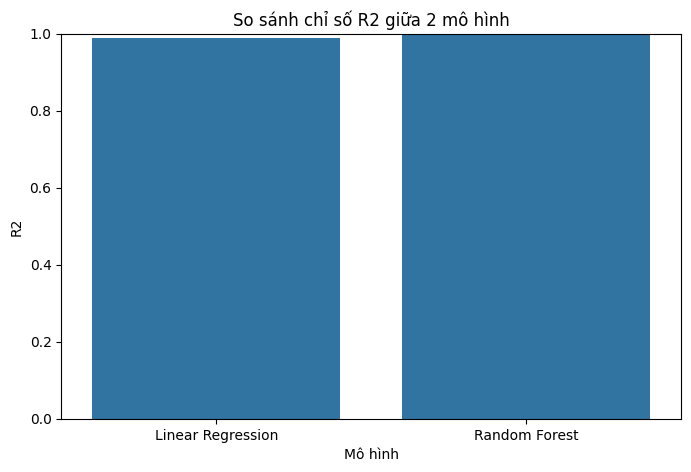

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x='Mô hình', y='R2', data=results)
plt.title('So sánh chỉ số R2 giữa 2 mô hình')
plt.ylim(0, 1)
plt.show()

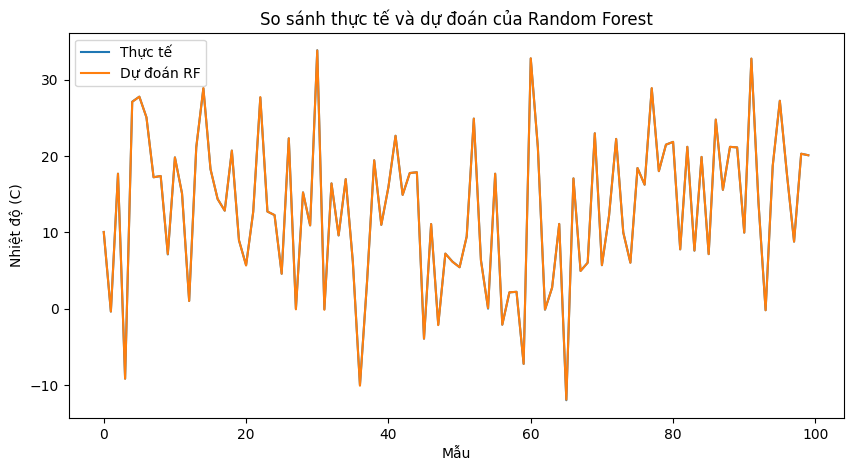

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Thực tế')
plt.plot(y_pred_rf[:100], label='Dự đoán RF')
plt.title('So sánh thực tế và dự đoán của Random Forest')
plt.xlabel('Mẫu')
plt.ylabel('Nhiệt độ (C)')
plt.legend()
plt.show()

In [12]:
feature_importance = pd.DataFrame({
    'Đặc trưng': X.columns,
    'Độ quan trọng': rf_model.feature_importances_
}).sort_values(by='Độ quan trọng', ascending=False)

feature_importance.head(10)

,Đặc trưng,Độ quan trọng
2,Apparent Temperature (C),0.974847
1,Precip Type,0.018039
4,Wind Speed (km/h),0.006298
3,Humidity,0.000774
6,Visibility (km),0.000012
8,Pressure (millibars),0.000010
13,Hour,0.000005
5,Wind Bearing (degrees),0.000003
12,Day,0.000003
9,Daily Summary,0.000003


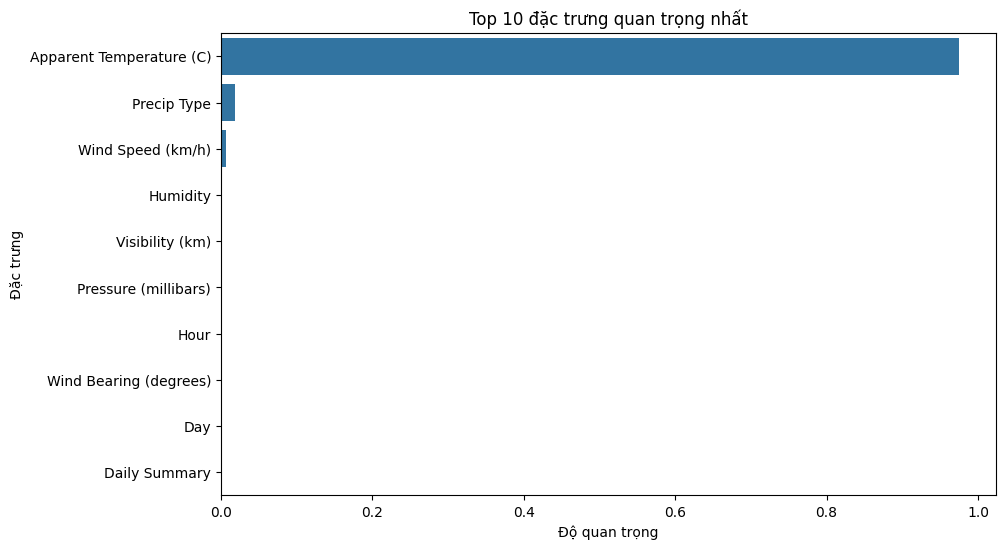

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x='Độ quan trọng', y='Đặc trưng', data=feature_importance.head(10))
plt.title('Top 10 đặc trưng quan trọng nhất')
plt.show()

In [14]:
du_bao = pd.DataFrame({
    'Thực tế': y_test.values[:10],
    'Dự đoán Linear Regression': y_pred_lr[:10],
    'Dự đoán Random Forest': y_pred_rf[:10]
})

du_bao

,Thực tế,Dự đoán Linear Regression,Dự đoán Random Forest
0,10.055556,11.293803,10.055556
1,-0.366667,1.013257,-0.368222
2,17.688889,17.297158,17.688889
3,-9.150000,-6.288584,-9.166222
4,27.122222,26.763279,27.095833
5,27.777778,27.444925,27.776111
6,25.072222,24.460742,25.072222
7,17.222222,16.585339,17.222222
8,17.388889,16.690507,17.388944
9,7.116667,6.981968,7.170722


In [15]:
du_bao_ket_qua = pd.DataFrame({
    'Gia tri thuc te': y_test.values,
    'Du doan Linear Regression': y_pred_lr,
    'Du doan Random Forest': y_pred_rf
})

du_bao_ket_qua.to_csv('ket_qua_du_bao_thoi_tiet.csv', index=False)
print("Đã lưu file ket_qua_du_bao_thoi_tiet.csv")

Đã lưu file ket_qua_du_bao_thoi_tiet.csv


In [16]:
if r2_rf > r2_lr:
    print("Mô hình Random Forest dự báo tốt hơn Linear Regression.")
else:
    print("Mô hình Linear Regression dự báo tốt hơn Random Forest.")

Mô hình Random Forest dự báo tốt hơn Linear Regression.


In [17]:
print("NHẬN XÉT CUỐI BÀI:")
print("- Dữ liệu đã được làm sạch và tiền xử lý.")
print("- Đã trực quan hóa một số đặc trưng quan trọng của dữ liệu thời tiết.")
print("- Đã xây dựng 2 mô hình dự báo nhiệt độ.")
print("- Đã đánh giá mô hình bằng các chỉ số MAE, MSE, RMSE, R2.")
print("- Chọn mô hình có độ chính xác tốt hơn để phục vụ dự báo thời tiết.")

NHẬN XÉT CUỐI BÀI:
- Dữ liệu đã được làm sạch và tiền xử lý.
- Đã trực quan hóa một số đặc trưng quan trọng của dữ liệu thời tiết.
- Đã xây dựng 2 mô hình dự báo nhiệt độ.
- Đã đánh giá mô hình bằng các chỉ số MAE, MSE, RMSE, R2.
- Chọn mô hình có độ chính xác tốt hơn để phục vụ dự báo thời tiết.
